Installs version 2 of the SageMaker SDK. The '--quiet' option is to suppress the installation log to keep the output concise and other dependencies

In [1]:
%pip install "sagemaker>=2.200,<3" --quiet
import boto3
import numpy as np
import pandas as pd

Note: you may need to restart the kernel to use updated packages.


Creates a SageMaker session and retrieves the AWS region and execution role. This confirms that the notebook can successfully connect to AWS and access the required resources.

In [2]:
import sagemaker
import re

session = sagemaker.Session()
region = session.boto_region_name
role = sagemaker.get_execution_role()

print("SageMaker SDK version:", sagemaker.__version__)
print("AWS region:", region)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


/opt/conda/lib/python3.12/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


SageMaker SDK version: 2.257.6
AWS region: eu-west-2


Connects to the S3 bucket and lists the files stored under the main-trainingdata prefix, with each file's name and size.

In [3]:
import boto3

BUCKET = "main-drift-detection-bucket"
PREFIX = "main-trainingdata"

s3 = boto3.client("s3")

objects = s3.list_objects_v2(Bucket=BUCKET, Prefix=PREFIX)["Contents"]

for obj in objects:
    print(f'{obj["Key"]:50s} {obj["Size"]/1e6:8.1f} MB')

main-trainingdata/                                      0.0 MB
main-trainingdata/train_identity.csv                   26.5 MB
main-trainingdata/train_transaction.csv               683.4 MB


For a reproducible experiment and to create the folders needed to save graphs, evidence, and models, sets a fixed random seed so that the experiment produces consistent results when the code is run again.

In [4]:
import numpy as np
import random
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

folders = ["figs", "evidence", "models"]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("seed set:", SEED)
print("folders :", [folder for folder in folders if os.path.isdir(folder)])

seed set: 42
folders : ['figs', 'evidence', 'models']


Loads the 'train_identity.csv' file from S3 into a pandas DataFrame and prints the number of rows and columns.

In [5]:
import pandas as pd

ident = pd.read_csv(f"s3://{BUCKET}/{PREFIX}/train_identity.csv")
print("identity:", ident.shape)

identity: (144233, 41)


Loads the 'train_transaction.csv' file from S3 into pandas DataFrame and prints the number of rows and columns in the file

In [6]:
txn = pd.read_csv(f"s3://{BUCKET}/{PREFIX}/train_transaction.csv")
print("transaction:", txn.shape)

transaction: (590540, 394)


Creates an inventory table containing, for each source file: file name, number of rows, number of columns, and memory used in GB. It then saves that table as 'evidence/T1_raw_inventory.csv'.

In [7]:
inv = pd.DataFrame([
    {
        "file": "train_transaction.csv",
        "rows": len(txn),
        "columns": txn.shape[1],
     "memory_GB": round(txn.memory_usage(deep=True).sum()/1e9, 2)
    },
    {
        "file": "train_identity.csv",
        "rows": len(ident), 
        "columns": ident.shape[1],
     "memory_GB": round(ident.memory_usage(deep=True).sum()/1e9, 2)
    }
])
inv.to_csv("evidence/T1_raw_inventory.csv", index=False)
print(inv)

                    file    rows  columns  memory_GB
0  train_transaction.csv  590540      394       2.16
1     train_identity.csv  144233       41       0.15


Checks the total and available RAM on the instance to see how much headroom remained after the first load.

In [8]:
import psutil
vm = psutil.virtual_memory()
print(f"total: {vm.total/1e9:.1f} GB   available: {vm.available/1e9:.1f} GB")

total: 16.6 GB   available: 9.8 GB


Checks the column names in both files and counts how many columns share each prefix. This shows the structure of the transaction and identity data.

In [9]:
import re
from collections import Counter

def prefix(column):
    match = re.match(r"^([A-Za-z_]+?)(\d+)$", column)
    if match:
        return match.group(1)
    return column

print("transaction:", Counter(prefix(c) for c in txn.columns).most_common())
print()
print("identity   :", Counter(prefix(c) for c in ident.columns).most_common())

transaction: [('V', 339), ('D', 15), ('C', 14), ('M', 9), ('card', 6), ('addr', 2), ('dist', 2), ('TransactionID', 1), ('isFraud', 1), ('TransactionDT', 1), ('TransactionAmt', 1), ('ProductCD', 1), ('P_emaildomain', 1), ('R_emaildomain', 1)]

identity   : [('id_', 38), ('TransactionID', 1), ('DeviceType', 1), ('DeviceInfo', 1)]


Selects key transaction columns and displays the first 70 rows to get a look at the data. Seventy rows, to see at least one fraud case.

In [10]:
cols = [
    "TransactionID", "isFraud", "TransactionDT", "TransactionAmt",
        "ProductCD", "card4", "card6", "P_emaildomain"
]
txn[cols].head(70)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card4,card6,P_emaildomain
0,2987000,0,86400,68.500,W,discover,credit,NaN
1,2987001,0,86401,29.000,W,mastercard,credit,gmail.com
2,2987002,0,86469,59.000,W,visa,debit,outlook.com
3,2987003,0,86499,50.000,W,mastercard,debit,yahoo.com
4,2987004,0,86506,50.000,H,mastercard,credit,gmail.com
...,...,...,...,...,...,...,...,...
65,2987065,0,87650,114.950,W,visa,debit,NaN
66,2987066,0,87660,300.000,H,visa,credit,anonymous.com
67,2987067,0,87664,445.000,W,visa,credit,NaN
68,2987068,0,87667,3.081,C,visa,credit,hotmail.com


legitimate : 569,877
fraud      : 20,663
fraud rate : 3.4990%


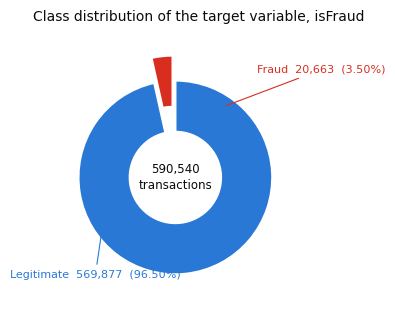

In [11]:
import matplotlib.pyplot as plt

# count fraudulent transactions
counts = txn["isFraud"].value_counts().sort_index()

legit = int(counts[0])
fraud = int(counts[1])
total = legit + fraud

pct_fraud = fraud / total * 100
pct_legit = 100 - pct_fraud

print(f"legitimate : {legit:,}")
print(f"fraud      : {fraud:,}")
print(f"fraud rate : {pct_fraud:.4f}%")



blue = "#2a78d6"     # legitimate
red  = "#d92d20"     # fraud
ink  = "#0b0b0b"     # text

fig, ax = plt.subplots(figsize=(4.8, 3.4))

ax.pie(
    [pct_legit, pct_fraud],
    colors       = [blue, red],
    explode      = (0, 0.22),
    startangle   = 90,
    counterclock = False,
    radius       = 0.85,
    wedgeprops   = dict(width=0.45, edgecolor="white", linewidth=1.6),
)

ax.text(0, 0, f"{total:,}\ntransactions",
        ha="center", va="center", fontsize=8.5, color=ink, linespacing=1.35)

ax.annotate(f"Fraud  {fraud:,}  ({pct_fraud:.2f}%)",
            xy=(0.42, 0.62), xytext=(0.72, 0.92),
            color=red, fontsize=8, ha="left",
            arrowprops=dict(arrowstyle="-", color=red, lw=0.8))

ax.annotate(f"Legitimate  {legit:,}  ({pct_legit:.2f}%)",
            xy=(-0.62, -0.30), xytext=(-1.45, -0.88),
            color=blue, fontsize=8, ha="left",
            arrowprops=dict(arrowstyle="-", color=blue, lw=0.8))

ax.set_title("Class distribution of the target variable, isFraud",
             loc="left", fontsize=10, color=ink, pad=10)

plt.tight_layout()
plt.savefig("figs/fig_class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()



counts.rename({0: "legitimate", 1: "fraud"}).to_csv(
    "evidence/T5_class_distribution.csv"
)

Calculates the fraud rate, the time span covered by the transactions, and the percentage of transactions with identity information. 'TransactionDT' is recorded in seconds rather than dates, so dividing by 86,400 converts the time span into days. This gives the 182-day period used for the window schedule.

In [12]:
span_days = (txn["TransactionDT"].max() - txn["TransactionDT"].min()) / 86400

print(f"fraud rate: {txn['isFraud'].mean():.4%}")
print(f"TransactionDT span: {span_days:.1f} days")
print(f"identity coverage : {len(ident) / len(txn):.2%} of transactions")

fraud rate: 3.4990%
TransactionDT span: 182.0 days
identity coverage : 24.42% of transactions


Groups the transaction and identity columns by their name prefix and calculates the average amount of missing data in each group. The results are saved as a CSV file for later analysis.

In [13]:
def group_of(c):
    if c == "TransactionID":
        return "identifier"
    if c == "isFraud":
        return "target"
    if c == "TransactionDT":
        return "time"
    if c.endswith("emaildomain"):
        return "email domain"
    if c.startswith("Device"):
        return "device"
    if c.startswith("id_"):
        return "id — identity"
    if c.startswith("card"):
        return "card attributes"
    if c.startswith("addr"):
        return "address"
    if c.startswith("dist"):
        return "distance"
    if c.startswith("V"):
        return "V — Vesta engineered"
    if c.startswith("C"):
        return "C — counting"
    if c.startswith("D"):
        return "D — timedelta"
    if c.startswith("M"):
        return "M — match flags"
    return "transaction attributes"


def profile(df, label):
    p = pd.DataFrame({"column": df.columns})
    p["group"] = p["column"].map(group_of)
    p["missing"] = p["column"].map(lambda c: df[c].isna().mean())
    
    out = p.groupby("group").agg(
        n_columns=("column", "size"), 
        mean_missing=("missing", "mean")
    )
    out = out.sort_values("n_columns", ascending=False)
    out = out.round(3).reset_index()
    out.insert(0, "source", label)
    return out


groups = pd.concat([profile(txn, "transaction"), profile(ident, "identity")])
groups.to_csv("evidence/T2_column_groups.csv", index=False)

print(groups.to_string(index=False))

     source                  group  n_columns  mean_missing
transaction   V — Vesta engineered        339         0.430
transaction          D — timedelta         15         0.582
transaction           C — counting         14         0.000
transaction        M — match flags          9         0.499
transaction        card attributes          6         0.005
transaction                address          2         0.111
transaction               distance          2         0.766
transaction           email domain          2         0.464
transaction transaction attributes          2         0.000
transaction             identifier          1         0.000
transaction                 target          1         0.000
transaction                   time          1         0.000
   identity          id — identity         38         0.379
   identity                 device          2         0.100
   identity             identifier          1         0.000


Joins the transaction and identity datasets using 'TransactionID', checks how many transactions have matching identity information, and compares fraud rates for transactions with and without identity data.

In [14]:
before = len(txn)

df = txn.merge(
    ident, on="TransactionID", how="left", indicator=True
)

df["has_identity"] = (df["_merge"] == "both").astype(int)

match_rate = df["has_identity"].mean()

df = df.drop(columns="_merge")

join = pd.DataFrame([{
    "rows_before_join": before,
    "rows_after_join": len(df),
    "columns_after": df.shape[1],
    "identity_match_rate": round(match_rate, 4),
    "fraud_rate": round(df["isFraud"].mean(), 5),
    "fraud_rate_with_identity": round(
        df.loc[df["has_identity"] == 1, "isFraud"].mean(), 5
    ),
    "fraud_rate_without_identity": round(
        df.loc[df["has_identity"] == 0, "isFraud"].mean(), 5
    )
}])

join.to_csv("evidence/T3_join_summary.csv", index=False)

print(join.T)

                                        0
rows_before_join             590540.00000
rows_after_join              590540.00000
columns_after                   435.00000
identity_match_rate               0.24420
fraud_rate                        0.03499
fraud_rate_with_identity          0.07847
fraud_rate_without_identity       0.02094


Identifies identity columns with very little data or no useful variation, records the columns being removed, and drops them from the dataset.

In [15]:
ident_cols = [c for c in df.columns
              if c.startswith("id_") or c in ("DeviceType", "DeviceInfo")]

DEAD = [c for c in ident_cols
        if df[c].notna().mean() < 0.01 or df[c].nunique(dropna=True) <= 1]

print(f"dropping {len(DEAD)} of {len(ident_cols)} identity columns:")

for c in DEAD:
    print(
        f"  {c:14s} coverage={df[c].notna().mean():.4f} "
    f"distinct={df[c].nunique(dropna=True)}"
    )

with open("evidence/dropped_columns.txt", "w") as f:
    f.write("\n".join(DEAD))

df = df.drop(columns=DEAD)
print(f"\nremaining: {df.shape}")

dropping 9 of 40 identity columns:
  id_07          coverage=0.0087 distinct=84
  id_08          coverage=0.0087 distinct=94
  id_21          coverage=0.0087 distinct=490
  id_22          coverage=0.0088 distinct=25
  id_23          coverage=0.0088 distinct=3
  id_24          coverage=0.0080 distinct=12
  id_25          coverage=0.0087 distinct=341
  id_26          coverage=0.0087 distinct=95
  id_27          coverage=0.0088 distinct=2

remaining: (590540, 426)


The last 84 days are set aside for the streaming period, leaving the first 98 days for training and validation. 84 ÷ 7 = 12, the streaming data forms twelve 7-day windows. For each window, the number of transactions, fraud cases, and fraud rate are calculated. 

In [16]:
WINDOW_DAYS = 7
N_WINDOWS   = 12

t0 = df["TransactionDT"].min()
df["day"] = (df["TransactionDT"] - t0) / 86400

stream_start = df["day"].max() - WINDOW_DAYS * N_WINDOWS

print(f"training/validation: days 0 – {stream_start:.1f}")
print(f"stream : days {stream_start:.1f} – {df['day'].max():.1f}\n")

rows = []

for i in range(N_WINDOWS):
    start_day = stream_start + i * WINDOW_DAYS
    end_day = start_day + WINDOW_DAYS
    
    window  = df[(df.day >= start_day) & (df.day < end_day)]
    
    rows.append({
        "window": i,
        "day_from": round(start_day, 1),
        "day_to": round(end_day, 1),
        "rows": len(window),
        "fraud": int(window["isFraud"].sum()),
        "fraud_rate": round(window["isFraud"].mean(), 5),
    })

window_summary = pd.DataFrame(rows)

window_summary.to_csv("evidence/window_summary.csv", index=False)

print(window_summary.to_string(index=False))

training/validation: days 0 – 98.0
stream : days 98.0 – 182.0

 window  day_from  day_to  rows  fraud  fraud_rate
      0      98.0   105.0 21270    718     0.03376
      1     105.0   112.0 20889    866     0.04146
      2     112.0   119.0 21079   1069     0.05071
      3     119.0   126.0 23576    833     0.03533
      4     126.0   133.0 19260    727     0.03775
      5     133.0   140.0 18568    610     0.03285
      6     140.0   147.0 18552    640     0.03450
      7     147.0   154.0 21443    660     0.03078
      8     154.0   161.0 19808    565     0.02852
      9     161.0   168.0 21037    729     0.03465
     10     168.0   175.0 19943    733     0.03675
     11     175.0   182.0 17755    747     0.04207


Splits the data into a training set covering the first 98 days and twelve 7-day streaming windows. Each split is saved as a separate Parquet file for use later in the experiment.

In [17]:
import os

os.makedirs("data/splits", exist_ok=True)

train = df[df["day"] < stream_start].copy()
train.to_parquet("data/splits/train.parquet", index=False)

for i in range(N_WINDOWS):
    start_day = stream_start + i * WINDOW_DAYS
    end_day = start_day + WINDOW_DAYS
    
    window  = df[(df["day"] >= start_day) & (df["day"] < end_day)]
    window.to_parquet(f"data/splits/stream_w{i:02d}.parquet", index=False)

print(f"train: {train.shape}")
print(f"saved {N_WINDOWS} stream windows")

train: (347359, 427)
saved 12 stream windows


Prepares the training data by removing columns the model should not see, changing categorical values into numbers, and separating the input data ('X_train') from the fraud target ('y_train').

In [18]:
# Columns that shouldn't be seen by the model
EXCLUDE = ["TransactionID", "TransactionDT", "day", "isFraud"]

cat_cols = [
    c for c in train.columns
    if train[c].dtype == "object" and c not in EXCLUDE
]

print(f"{len(cat_cols)} categorical columns")

# numbering each category
cat_maps = {}

for c in cat_cols:
    values = train[c].dropna().unique()
    cat_maps[c] = {v: i for i, v in enumerate(values)}


def encode(frame):
    X = frame.drop(
        columns=[c for c in EXCLUDE if c in frame.columns]
    ).copy()
    
    for c in cat_cols:
        X[c] = X[c].map(cat_maps[c]).fillna(-1).astype("int32")
    return X

X_train = encode(train)
y_train = train["isFraud"].values

print("X_train:", X_train.shape)

29 categorical columns
X_train: (347359, 423)


Splits the training data into a fitting set and a 14-day validation set, converts both into model inputs, and compares the fraud rates in each.

In [19]:
import xgboost as xgb

VAL_DAYS  = 14
val_start = stream_start - VAL_DAYS

fit = train[train.day <  val_start]
val = train[train.day >= val_start]

X_fit, y_fit = encode(fit), fit["isFraud"].values
X_val, y_val = encode(val), val["isFraud"].values

print(f"fit: days 0 – {val_start:.0f}   {X_fit.shape}")
print(f"validation: days {val_start:.0f} – {stream_start:.0f}   {X_val.shape}")
print(f"fraud rate — fit {y_fit.mean():.4%} | val {y_val.mean():.4%}")

fit: days 0 – 84   (297541, 423)
validation: days 84 – 98   (49818, 423)
fraud rate — fit 3.3508% | val 3.6051%


Trains an XGBoost champion model using the fitting data, gives more weight to the less common fraud class, and uses the validation data to find the best training point.

In [20]:
SPW = (y_fit == 0).sum() / (y_fit == 1).sum()
print(f"scale_pos_weight = {SPW:.2f}")

params = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "scale_pos_weight": SPW,
    "seed": SEED,
    "max_depth": 6,
    "eta": 0.1,
}

dfit = xgb.DMatrix(X_fit, label=y_fit)
dval = xgb.DMatrix(X_val, label=y_val)

bst = xgb.train(
    params,
    dfit,
    num_boost_round = 500,
    evals = [(dfit, "train"), (dval, "val")],
    early_stopping_rounds= 50,
    verbose_eval = 50,
)

print(f"\nbest iteration : {bst.best_iteration}")
print(f"best val aucpr : {bst.best_score:.4f}")

scale_pos_weight = 28.84
[0]	train-aucpr:0.35277	val-aucpr:0.30761
[50]	train-aucpr:0.65046	val-aucpr:0.46354
[100]	train-aucpr:0.71362	val-aucpr:0.48473
[150]	train-aucpr:0.75292	val-aucpr:0.49567
[200]	train-aucpr:0.78536	val-aucpr:0.49911
[250]	train-aucpr:0.81013	val-aucpr:0.50418
[300]	train-aucpr:0.83530	val-aucpr:0.50602
[350]	train-aucpr:0.85558	val-aucpr:0.50855
[400]	train-aucpr:0.87292	val-aucpr:0.50927
[433]	train-aucpr:0.88202	val-aucpr:0.50872

best iteration : 384
best val aucpr : 0.5098


In [21]:
# Saves the trained model and prints the best training iteration and validation score.
bst.save_model("models/champion.json")
print("saved:", bst.best_iteration, round(bst.best_score, 4))

saved: 384 0.5098


Ranks the features based on how useful they were to the model and shows the top 10 alongside their data coverage. Which reveals that the most useful feature, V258, is present in only 27.4% of rows.

In [22]:
gain   = bst.get_score(importance_type="gain")
ranked = sorted(gain.items(), key=lambda x: x[1], reverse=True)

print(f"{len(gain)} of {X_fit.shape[1]} features available\n")
print("top 10 by gain:")

for name, value in ranked[:10]:
    if name in X_fit:
        coverage = X_fit[name].notna().mean()
    else:
        coverage = float("nan")
        
    print(f"  {name:16s} gain={value:10.1f}  coverage={coverage:.3f}")

393 of 423 features available

top 10 by gain:
  V258             gain=    8403.0  coverage=0.274
  V70              gain=    4426.7  coverage=0.815
  V294             gain=    3232.6  coverage=1.000
  V187             gain=    1581.2  coverage=0.288
  V91              gain=    1438.1  coverage=0.805
  C14              gain=     978.3  coverage=1.000
  C8               gain=     927.3  coverage=1.000
  C4               gain=     819.3  coverage=1.000
  V141             gain=     688.2  coverage=0.193
  card6            gain=     530.1  coverage=1.000


 Outputs how many features were available to the model, how many were actually used, and how many were never used in a split.

In [23]:
print(f"features available : {X_fit.shape[1]}")
print(f"features used      : {len(gain)}")
print(f"never split on     : {X_fit.shape[1] - len(gain)}\n")

features available : 423
features used      : 393
never split on     : 30



Builds a reference distribution for each monitored feature proportion per level for categorical columns, proportions per quantile bin for numeric ones ignoring missing values, and drops any feature with insufficient coverage or too few distinct bins.

In [26]:
import numpy as np

def psi_baseline(X, cols, cat_cols, n_bins=10, min_coverage=0.5, min_edges=6):
    # Learn the expected distribution of each monitored feature.
    reference = {} 
    dropped = []

    for c in cols:
        s = X[c]
# skip colums with many missing values
        if s.notna().mean() < min_coverage:
            dropped.append((c, "coverage"))
            continue

        s = s.dropna()

        if c in cat_cols:
            proportions = s.value_counts(normalize=True)
            
            reference[c] = {
                "type": "cat",
                "levels": proportions.index.tolist(),
                "p": proportions.values.tolist()
            }
        else:
            edges = np.unique(
                np.quantile(s, np.linspace(0, 1, n_bins + 1))
            )
# skip colums without enough different values
            if len(edges) < min_edges:
                dropped.append((c, "degenerate bins"))
                continue

            edges[0], edges[-1] = -np.inf, np.inf
            
            counts = np.histogram(s, bins=edges)[0]
            reference[c] = {
                "type": "num",
                "edges": edges.tolist(),
                "p": (counts / counts.sum()).tolist()}

    return reference, dropped


REF, dropped = psi_baseline(X_fit, monitored, cat_cols)

print(f"reference built on {len(REF)} of {len(monitored)} monitored features")

for c, why in dropped:
    print(f"  dropped {c:16s} ({why})")

reference built on 4 of 20 monitored features
  dropped V70              (degenerate bins)
  dropped V294             (degenerate bins)
  dropped V91              (degenerate bins)
  dropped C8               (degenerate bins)
  dropped C4               (degenerate bins)
  dropped C10              (degenerate bins)
  dropped V49              (degenerate bins)
  dropped V30              (degenerate bins)
  dropped V308             (degenerate bins)
  dropped V93              (degenerate bins)
  dropped V312             (degenerate bins)
  dropped V72              (degenerate bins)
  dropped V128             (degenerate bins)
  dropped V34              (degenerate bins)
  dropped C11              (degenerate bins)
  dropped addr2            (degenerate bins)


Selects the top 20 features by gain that have at least 50 per cent data coverage, records those falling below the coverage threshold, and saves both lists as evidence files.

In [25]:
MIN_COVERAGE = 0.5
N_MONITOR = 20

candidates, excluded = [], []
for name, g in ranked:
    if name not in X_fit.columns:
        continue
    cov = X_fit[name].notna().mean()
    (candidates if cov >= MIN_COVERAGE else excluded).append((name, g, cov))

monitored = [n for n, g, c in candidates[:N_MONITOR]]

print(f"monitored ({len(monitored)}):")
for n, g, c in candidates[:N_MONITOR]:
    print(f"  {n:16s} gain={g:9.1f}  coverage={c:.3f}")

print("\nexcluded by coverage — top 5 by gain:")
for n, g, c in excluded[:5]:
    print(f"  {n:16s} gain={g:9.1f}  coverage={c:.3f}")

with open("evidence/monitored_features.txt", "w") as f:
    f.write("\n".join(monitored))

pd.DataFrame(excluded[:20], columns=["feature", "gain", "coverage"]).to_csv(
    "evidence/excluded_by_coverage.csv", index=False)

monitored (20):
  V70              gain=   4426.7  coverage=0.815
  V294             gain=   3232.6  coverage=1.000
  V91              gain=   1438.1  coverage=0.805
  C14              gain=    978.3  coverage=1.000
  C8               gain=    927.3  coverage=1.000
  C4               gain=    819.3  coverage=1.000
  card6            gain=    530.1  coverage=1.000
  C10              gain=    484.6  coverage=1.000
  V49              gain=    426.0  coverage=0.668
  M4               gain=    410.7  coverage=1.000
  V30              gain=    365.7  coverage=0.818
  V308             gain=    347.2  coverage=1.000
  V93              gain=    347.0  coverage=0.805
  C1               gain=    326.3  coverage=1.000
  V312             gain=    307.7  coverage=1.000
  V72              gain=    294.7  coverage=0.815
  V128             gain=    292.0  coverage=1.000
  V34              gain=    276.8  coverage=0.818
  C11              gain=    276.7  coverage=1.000
  addr2            gain=    268.8 

This code creates a baseline distribution for the monitored features so that later data can be compared against it for PSI-based drift detection.

In [27]:
def psi_baseline(X, cols, cat_cols, n_bins=10,
                 min_coverage=0.5, min_bins=3, min_bin_prop=0.01):
    # Create the reference distribution of each monitored feature
    ref, dropped = {}, []

    for c in cols:
        s = X[c]

        # ignore features with too much missing data
        if s.notna().mean() < min_coverage:
            dropped.append((c, "coverage"))
            continue

        s = s.dropna()

        # Store the proportions for categorical features
        if c in cat_cols:
            p = s.value_counts(normalize=True)
            ref[c] = {
                "type": "cat",
                "levels": p.index.tolist(),
                "p": p.values.tolist()
            }
            continue

        # Create bins for numerical features
        edges = np.unique(
            np.quantile(s, np.linspace(0, 1, n_bins + 1))
        )

        # Ignores features that do not have enough bins
        if len(edges) - 1 < min_bins:
            dropped.append((c, f"only {len(edges)-1} bins"))
            continue

        edges[0], edges[-1] = -np.inf, np.inf
        
        counts = np.histogram(s, bins=edges)[0]
        p = counts / counts.sum()

        # Ignore features in any of the bin with few values
        if p.min() < min_bin_prop:
            dropped.append((c, f"sparsest bin {p.min():.4f}"))
            continue

        ref[c] = {
            "type": "num",
            "edges": edges.tolist(),
            "p": p.tolist()
        }

    return ref, dropped


REF, dropped = psi_baseline(X_fit, monitored, cat_cols)

print(f"reference built on {len(REF)} of {len(monitored)} features")
print("kept:", sorted(REF.keys()), "\n")

for c, why in dropped:
    print(f"  dropped {c:16s} ({why})")

reference built on 5 of 20 features
kept: ['C14', 'M4', 'V128', 'V308', 'card6'] 

  dropped V70              (only 2 bins)
  dropped V294             (only 2 bins)
  dropped V91              (only 2 bins)
  dropped C8               (only 2 bins)
  dropped C4               (only 2 bins)
  dropped C10              (only 2 bins)
  dropped V49              (only 2 bins)
  dropped V30              (only 2 bins)
  dropped V93              (only 2 bins)
  dropped C1               (sparsest bin 0.0008)
  dropped V312             (only 2 bins)
  dropped V72              (only 2 bins)
  dropped V34              (only 2 bins)
  dropped C11              (sparsest bin 0.0012)
  dropped addr2            (only 2 bins)


Checks if the five features chosen for drift injection are in the monitored set so that the detector has a chance of seeing the shift before the experiment is run.

In [28]:
# Drift injection targets 
targets = ["TransactionAmt", "C1", "C13", "C14", "card6"]
for t in targets:
    where = "monitored" if t in REF else ("dropped" if t in monitored else "not in top-20")
    print(f"{t:16s} {where}")

TransactionAmt   not in top-20
C1               dropped
C13              not in top-20
C14              monitored
card6            monitored


Runs the ranked list until it has 20 monitorable features, builds a reference distribution for each, records the ones that fail the coverage or bin requirements along with the reason, and saves both lists as evidence.

In [29]:
MIN_COVERAGE = 0.5
MIN_BINS = 2
MIN_BIN_PROP = 0.01
N_BINS = 10
N_MONITOR = 20

def make_ref(s, is_cat):
    # Return (entry, None) if the feature is monitorable, else (None, reason)
    if s.notna().mean() < MIN_COVERAGE:
        return None, f"coverage {s.notna().mean():.3f}"
    s = s.dropna()

    if is_cat:
        p = s.value_counts(normalize=True)
        if p.min() < MIN_BIN_PROP and len(p) > 2:
            return None, f"rarest level {p.min():.4f}"
        return {"type": "cat", "levels": p.index.tolist(),
                "p": p.values.tolist()}, None

    edges = np.unique(np.quantile(s, np.linspace(0, 1, N_BINS + 1)))
    if len(edges) - 1 < MIN_BINS:
        return None, f"only {len(edges)-1} bins"

    edges[0], edges[-1] = -np.inf, np.inf
    p = np.histogram(s, bins=edges)[0]
    p = p / p.sum()
    if p.min() < MIN_BIN_PROP:
        return None, f"sparsest bin {p.min():.4f}"

    return {"type": "num", "edges": edges.tolist(), "p": p.tolist()}, None


REF, monitored, rejected = {}, [], []

for name, g in ranked:
    if len(monitored) >= N_MONITOR:
        break
    if name not in X_fit.columns:
        continue
    entry, why = make_ref(X_fit[name], name in cat_cols)
    if entry is None:
        rejected.append((name, round(g, 1), why))
    else:
        REF[name] = entry
        monitored.append(name)

print(f"monitoring {len(monitored)} features:")
print(" ", ", ".join(monitored), "\n")
print(f"rejected {len(rejected)} higher-gain features along the way:")
for n, g, why in rejected[:12]:
    print(f"  {n:16s} gain={g:9.1f}  {why}")

with open("evidence/monitored_features.txt", "w") as f:
    f.write("\n".join(monitored))
pd.DataFrame(rejected, columns=["feature", "gain", "reason"]).to_csv(
    "evidence/rejected_features.csv", index=False)

monitoring 20 features:
  V70, V294, V91, C14, C8, C4, C10, V49, M4, V30, V308, V93, V312, V72, V128, V34, ProductCD, D3, V62, V50 

rejected 21 higher-gain features along the way:
  V258             gain=   8403.0  coverage 0.274
  V187             gain=   1581.2  coverage 0.288
  V141             gain=    688.2  coverage 0.193
  card6            gain=    530.1  rarest level 0.0000
  V330             gain=    423.9  coverage 0.193
  V326             gain=    388.2  coverage 0.193
  V163             gain=    357.3  coverage 0.193
  V198             gain=    348.7  coverage 0.288
  V324             gain=    340.3  coverage 0.193
  V189             gain=    329.5  coverage 0.288
  C1               gain=    326.3  sparsest bin 0.0008
  D2               gain=    284.6  coverage 0.488


This code creates a reference distribution for categorical features, grouping rare categories into an __other__ category and rejecting features with only one remaining level.

In [30]:
def make_ref(s, is_cat):
    if s.notna().mean() < MIN_COVERAGE:
        return None, f"coverage {s.notna().mean():.3f}"
    s = s.dropna()

    if is_cat:
        p = s.value_counts(normalize=True)
        rare = p[p < MIN_BIN_PROP]
        if len(rare):
            p = pd.concat([p[p >= MIN_BIN_PROP],
                           pd.Series({"__other__": rare.sum()})])
        if len(p) < 2:
            return None, "single level"
        return {"type": "cat", "levels": p.index.tolist(),
                "p": p.values.tolist()}, None

Injects controlled data drift into selected features by scaling and adding noise to numerical values, changing some card6 categories to "credit", and increasing TransactionAmt, with the strength parameter controlling how much drift is introduced. The fraud labels are left unchanged; only the inputs shift.

In [31]:
def inject_drift(w, strength=1.0, seed=0):
    rng = np.random.default_rng(seed)
    d = w.copy()

    for c in ["C4", "C8", "C14"]:
        d[c] = d[c] * (1 + 0.6*strength) + rng.normal(0, 2*strength, len(d))

    m = rng.random(len(d)) < 0.5*strength
    d.loc[m, "card6"] = "credit"

    d["TransactionAmt"] = d["TransactionAmt"] * (1 + 0.8*strength)

    return d

Builds reference distributions for the selected features. Filters out features with insufficient coverage or sparse bins, runs down the ranking until 20 suitable features are found, and records the rejected features with the reason for each exclusion.

In [32]:
MIN_COVERAGE = 0.5
MIN_BINS = 2
MIN_BIN_PROP = 0.01
N_BINS = 10
N_MONITOR = 20


def make_ref(s, is_cat):
    # check if the feature is monitorable

    if s.notna().mean() < MIN_COVERAGE:
        return None, f"coverage {s.notna().mean():.3f}"

    s = s.dropna()

    if is_cat:
        p = s.value_counts(normalize=True)
        rare = p[p < MIN_BIN_PROP]
        if len(rare):
            p = pd.concat([p[p >= MIN_BIN_PROP],
                           pd.Series({"__other__": rare.sum()})])
        if len(p) < 2:
            return None, "single level"
        return {"type": "cat",
                "levels": p.index.tolist(),
                "p": p.values.tolist()}, None

    edges = np.unique(np.quantile(s, np.linspace(0, 1, N_BINS + 1)))
    if len(edges) - 1 < MIN_BINS:
        return None, f"only {len(edges)-1} bins"

    edges[0], edges[-1] = -np.inf, np.inf
    counts = np.histogram(s, bins=edges)[0]
    p = counts / counts.sum()
    if p.min() < MIN_BIN_PROP:
        return None, f"sparsest bin {p.min():.4f}"

    return {"type": "num",
            "edges": edges.tolist(),
            "p": p.tolist()}, None


REF, monitored, rejected = {}, [], []

for name, g in ranked:
    if len(monitored) >= N_MONITOR:
        break
    if name not in X_fit.columns:
        continue
    entry, why = make_ref(X_fit[name], name in cat_cols)
    if entry is None:
        rejected.append((name, round(g, 1), why))
    else:
        REF[name] = entry
        monitored.append(name)

print(f"monitoring {len(monitored)} features:")
print(" ", ", ".join(monitored), "\n")
print(f"rejected {len(rejected)} higher-gain features:")
for n, g, why in rejected[:12]:
    print(f"  {n:16s} gain={g:9.1f}  {why}")

with open("evidence/monitored_features.txt", "w") as f:
    f.write("\n".join(monitored))
pd.DataFrame(rejected, columns=["feature", "gain", "reason"]).to_csv(
    "evidence/rejected_features.csv", index=False)

print("\ncard6:", "monitored" if "card6" in REF else "still rejected")

monitoring 20 features:
  V70, V294, V91, C14, C8, C4, card6, C10, V49, M4, V30, V308, V93, V312, V72, V128, V34, ProductCD, D3, V62 

rejected 20 higher-gain features:
  V258             gain=   8403.0  coverage 0.274
  V187             gain=   1581.2  coverage 0.288
  V141             gain=    688.2  coverage 0.193
  V330             gain=    423.9  coverage 0.193
  V326             gain=    388.2  coverage 0.193
  V163             gain=    357.3  coverage 0.193
  V198             gain=    348.7  coverage 0.288
  V324             gain=    340.3  coverage 0.193
  V189             gain=    329.5  coverage 0.288
  C1               gain=    326.3  sparsest bin 0.0008
  D2               gain=    284.6  coverage 0.488
  V156             gain=    280.5  coverage 0.193

card6: monitored


Calculates the PSI score for each monitored feature by comparing its current distribution with the reference distribution. Handles categorical and numerical features separately, and applies a small value adjustment to avoid calculation errors.

In [33]:
def psi_score(ref, X, eps=1e-6):
    # Calculates PSI for each monitored feature compared with the reference data
    out = {}

    for c, r in ref.items():
        s = X[c]

        if r["type"] == "cat":
            cur = s.value_counts(normalize=True)
            a = [0.0 if l == "__other__" else float(cur.get(l, 0.0))
                 for l in r["levels"]]
            if "__other__" in r["levels"]:
                i = r["levels"].index("__other__")
                a[i] = max(0.0, 1.0 - sum(x for j, x in enumerate(a) if j != i))
            a = np.array(a)
        else:
            counts = np.histogram(s.dropna(), bins=np.array(r["edges"]))[0]
            a = counts / max(counts.sum(), 1)

        e = np.array(r["p"])
        e, a = np.clip(e, eps, None), np.clip(a, eps, None)
        e, a = e / e.sum(), a / a.sum()

        out[c] = float(np.sum((a - e) * np.log(a / e)))

    return out

In [35]:
# Calculates the average PSI between the fitting and validation data, then lists the PSI score for each monitored feature from highest to lowest.
psi_val  = psi_score(REF, X_val)
mean_psi = np.mean(list(psi_val.values()))

print(f"mean PSI, fit → validation: {mean_psi:.4f}\n")
for c, v in sorted(psi_val.items(), key=lambda kv: -kv[1]):
    print(f"  {c:14s} {v:.4f}")

mean PSI, fit → validation: 0.0363

  ProductCD      0.1919
  card6          0.1272
  C8             0.1159
  C10            0.1140
  C4             0.0898
  V93            0.0229
  V72            0.0161
  M4             0.0118
  D3             0.0070
  V49            0.0053
  C14            0.0048
  V91            0.0039
  V62            0.0036
  V30            0.0033
  V294           0.0033
  V70            0.0030
  V312           0.0016
  V34            0.0007
  V128           0.0006
  V308           0.0002


Calculates the model's prediction probabilities on the validation set. Finds the decision threshold that gives the highest F1 score and keeps the threshold for later classification.

In [36]:
from sklearn.metrics import (average_precision_score, f1_score,
                             precision_recall_curve)

p_val = bst.predict(xgb.DMatrix(X_val),
                    iteration_range=(0, bst.best_iteration + 1))

prec, rec, thr = precision_recall_curve(y_val, p_val)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
THRESH = float(thr[np.argmax(f1s[:-1])])

print(f"decision threshold (max F1 on validation): {THRESH:.4f}")

decision threshold (max F1 on validation): 0.7747


To evaluate the model across each stream window without drift injection. Recording fraud rate, PR-AUC, F1, and PSI metrics as the control results.

In [37]:
rows = []
for i in range(N_WINDOWS):
    w  = pd.read_parquet(f"data/splits/stream_w{i:02d}.parquet")
    Xw = encode(w)
    yw = w["isFraud"].values

    p   = bst.predict(xgb.DMatrix(Xw), iteration_range=(0, bst.best_iteration + 1))
    psi = psi_score(REF, Xw)
    vals = list(psi.values())

    rows.append({
        "window":     i,
        "n":          len(w),
        "fraud_rate": round(float(yw.mean()), 5),
        "pr_auc":     round(average_precision_score(yw, p), 4),
        "f1":         round(f1_score(yw, (p >= THRESH).astype(int)), 4),
        "psi_mean":   round(float(np.mean(vals)), 4),
        "psi_max":    round(float(np.max(vals)), 4),
    })

control = pd.DataFrame(rows)
control.to_csv("evidence/control_no_injection.csv", index=False)
print(control.to_string(index=False))

 window     n  fraud_rate  pr_auc     f1  psi_mean  psi_max
      0 21270     0.03376  0.4911 0.4662    0.0354   0.1564
      1 20889     0.04146  0.5273 0.5057    0.0171   0.1437
      2 21079     0.05071  0.5542 0.5416    0.0207   0.1664
      3 23576     0.03533  0.5586 0.5638    0.0287   0.1582
      4 19260     0.03775  0.4255 0.4654    0.0301   0.1322
      5 18568     0.03285  0.4409 0.4648    0.0219   0.1340
      6 18552     0.03450  0.3699 0.3856    0.0255   0.1302
      7 21443     0.03078  0.4677 0.4744    0.0314   0.1565
      8 19808     0.02852  0.4244 0.4311    0.0283   0.2328
      9 21037     0.03465  0.4265 0.4403    0.0078   0.0655
     10 19943     0.03675  0.4900 0.5008    0.0227   0.1756
     11 17755     0.04207  0.4904 0.4914    0.0220   0.1266


Bootstrap resampling to estimate a 95% confidence interval for PR-AUC on the best and worst control windows so that the difference between them can be judged against sampling variation.

In [38]:
def boot_ci(y, p, n=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    vals = [average_precision_score(y[s], p[s])
            for s in (rng.choice(idx, len(idx), replace=True) for _ in range(n))]
    return np.percentile(vals, [2.5, 97.5])

for i in (3, 6):
    w  = pd.read_parquet(f"data/splits/stream_w{i:02d}.parquet")
    Xw, yw = encode(w), w["isFraud"].values
    p  = bst.predict(xgb.DMatrix(Xw), iteration_range=(0, bst.best_iteration + 1))
    lo, hi = boot_ci(yw, p)
    print(f"window {i}: PR-AUC {average_precision_score(yw, p):.4f}  95% CI [{lo:.4f}, {hi:.4f}]")

window 3: PR-AUC 0.5586  95% CI [0.5228, 0.5953]
window 6: PR-AUC 0.3699  95% CI [0.3308, 0.4113]


In [39]:
# Prints the correlation between PR-AUC, mean PSI, maximum PSI and fraud rate across the control windows, to test if the monitor moves with model performance.
print(control[["pr_auc", "psi_mean", "psi_max", "fraud_rate"]].corr().round(3))

            pr_auc  psi_mean  psi_max  fraud_rate
pr_auc       1.000     0.009    0.208       0.574
psi_mean     0.009     1.000    0.570      -0.343
psi_max      0.208     0.570    1.000      -0.163
fraud_rate   0.574    -0.343   -0.163       1.000


Calculates the PR-AUC lift relative to the fraud rate, saves the updated control results, and displays the key performance and drift metrics.

In [40]:
control["lift"] = (control.pr_auc / control.fraud_rate).round(2)
control.to_csv("evidence/control_no_injection.csv", index=False)
print(control[["window", "fraud_rate", "pr_auc", "lift", "psi_mean"]].to_string(index=False))

 window  fraud_rate  pr_auc  lift  psi_mean
      0     0.03376  0.4911 14.55    0.0354
      1     0.04146  0.5273 12.72    0.0171
      2     0.05071  0.5542 10.93    0.0207
      3     0.03533  0.5586 15.81    0.0287
      4     0.03775  0.4255 11.27    0.0301
      5     0.03285  0.4409 13.42    0.0219
      6     0.03450  0.3699 10.72    0.0255
      7     0.03078  0.4677 15.19    0.0314
      8     0.02852  0.4244 14.88    0.0283
      9     0.03465  0.4265 12.31    0.0078
     10     0.03675  0.4900 13.33    0.0227
     11     0.04207  0.4904 11.66    0.0220


In [41]:
print(sorted(os.listdir("evidence")))

['T1_raw_inventory.csv', 'T2_column_groups.csv', 'T3_join_summary.csv', 'T5_class_distribution.csv', 'T6_confusion_w0.csv', 'arm_summary.csv', 'config.json', 'control_no_injection.csv', 'dropped_columns.txt', 'excluded_by_coverage.csv', 'friedman.csv', 'monitored_features.txt', 'nemenyi.csv', 'pr_auc_by_window.csv', 'rejected_features.csv', 'three_arms.csv', 'threshold_sweep.csv', 'window_summary.csv']


Injects controlled drift into selected features and retrains a candidate XGBoost model using the same training settings on label-mature data.

In [42]:
def inject_drift(w, strength=1.0, seed=0):
    # Inject a sustained shift into four monitored features and one unmonitored
    rng = np.random.default_rng(seed)
    d = w.copy()

    for c in ["C4", "C8", "C14"]:
        d[c] = d[c] * (1 + 0.6*strength) + rng.normal(0, 2*strength, len(d))

    m = rng.random(len(d)) < 0.5*strength
    d.loc[m, "card6"] = "credit"

    d["TransactionAmt"] = d["TransactionAmt"] * (1 + 0.8*strength)

    return d


def retrain_on(frame):
    # Rebuild a candidate model on label-mature data, identical settings
    X, y = encode(frame), frame["isFraud"].values
    spw  = (y == 0).sum() / max((y == 1).sum(), 1)

    p = dict(params)
    p["scale_pos_weight"] = spw

    return xgb.train(p, xgb.DMatrix(X, label=y),
                     num_boost_round=bst.best_iteration + 1)

In [43]:
import gc

for name in ["txn", "ident", "df", "X_train", "X_fit", "X_val",
             "dfit", "dval", "p_val"]:
    if name in globals():
        del globals()[name]

gc.collect()

vm = psutil.virtual_memory()
print(f"available: {vm.available/1e9:.1f} GB")

available: 9.7 GB


In [49]:
import os
import gc
import time
import random
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import average_precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve

# set the seed so the results are the same every time
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# experiment settings
WINDOW_DAYS = 7
N_WINDOWS = 12
GAP_WINDOWS = 1
ONSET = 4
RETRAIN_ROWS = 150000
BEST_ITER = 384

# load the training data that was saved
train = pd.read_parquet("data/splits/train.parquet")

# split it into a fitting part and a 14 day validation part
val_start = train.day.max() - 14
fit = train[train.day < val_start]
val = train[train.day >= val_start]

# columns visible to the model
EXCLUDE = ["TransactionID", "TransactionDT", "day", "isFraud"]

# find the text columns
cat_cols = []
for c in train.columns:
    if train[c].dtype == "object" and c not in EXCLUDE:
        cat_cols.append(c)

# give each text value a number, using the fitting data only
cat_maps = {}
for c in cat_cols:
    values = fit[c].dropna().unique()
    cat_maps[c] = {}
    for i, v in enumerate(values):
        cat_maps[c][v] = i

# turn a dataframe into model input
def encode(frame):
    X = frame.copy()
    for c in EXCLUDE:
        if c in X.columns:
            X = X.drop(columns=c)
    for c in cat_cols:
        X[c] = X[c].map(cat_maps[c])
        X[c] = X[c].fillna(-1)
        X[c] = X[c].astype("int32")
    return X

X_fit = encode(fit)

# load the champion model that was trained earlier
bst = xgb.Booster()
bst.load_model("models/champion.json")
RANGE = (0, BEST_ITER + 1)

# rank the features by how useful they were
gain = bst.get_score(importance_type="gain")
ranked = sorted(gain.items(), key=lambda x: x[1], reverse=True)

# find the threshold that gives the best F1 on the validation data
X_val = encode(val)
y_val = val["isFraud"].values
p_val = bst.predict(xgb.DMatrix(X_val), iteration_range=RANGE)

prec, rec, thr = precision_recall_curve(y_val, p_val)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
THRESH = float(thr[np.argmax(f1s[:-1])])

print("train shape:", train.shape)
print("threshold:", round(THRESH, 4))

train shape: (347359, 427)
threshold: 0.7747


Simulates the retraining policies across the stream windows. Applies drift from the onset window (window 4) when enabled, evaluates model performance and PSI, retrains when triggered, and promotes the candidate if it performs better on the matured holdout window.

In [50]:
def simulate(policy, tau=0.70, cadence=3, inject=True, strength=1.0):
    champ = xgb.Booster()
    champ.load_model("models/champion.json")

    labelled = train.tail(RETRAIN_ROWS).copy()
    holdout  = None
    buf      = []

    rows, n_retrain, n_promote = [], 0, 0

    for i in range(N_WINDOWS):
        w = pd.read_parquet(f"data/splits/stream_w{i:02d}.parquet")
        if inject and i >= ONSET:
            w = inject_drift(w, strength=strength, seed=i)

        Xw, yw = encode(w), w["isFraud"].values
        dw = xgb.DMatrix(Xw)

        p     = champ.predict(dw, iteration_range=RANGE)
        pr    = average_precision_score(yw, p)
        f1    = f1_score(yw, (p >= THRESH).astype(int))
        psi_m = float(np.mean(list(psi_score(REF, Xw).values())))

        del Xw, dw

        fire = ((policy == "scheduled" and i > 0 and i % cadence == 0) or
                (policy == "psi"       and psi_m > tau))

        promoted, secs = False, 0.0

        if fire and holdout is not None:
            n_retrain += 1
            t0   = time.time()
            cand = retrain_on(labelled)
            secs = time.time() - t0

            Xh, yh = encode(holdout), holdout["isFraud"].values
            dh = xgb.DMatrix(Xh)
            if (average_precision_score(yh, cand.predict(dh)) >
                average_precision_score(yh, champ.predict(dh, iteration_range=RANGE))):
                champ, promoted = cand, True
                n_promote += 1
            del Xh, dh, cand
            gc.collect()

        rows.append({
            "window": i, "policy": policy,
            "pr_auc": round(pr, 4), "f1": round(f1, 4),
            "psi_mean": round(psi_m, 4),
            "fired": int(fire), "promoted": int(promoted),
            "n_retrain_cum": n_retrain, "train_secs": round(secs, 1),
        })

        # move windows through the gap
        buf.append(w)
        if len(buf) > GAP_WINDOWS:
            matured = buf.pop(0)
            if holdout is not None:
                labelled = pd.concat([labelled, holdout],
                                     ignore_index=True).tail(RETRAIN_ROWS)
            holdout = matured

    return pd.DataFrame(rows), n_retrain, n_promote

Runs the static, scheduled, and PSI-based retraining arms using a provisional PSI threshold, records their performance and retraining counts, and saves the combined results as evidence.

In [51]:
arms = {}

for name, kwargs in [("static",    {"policy": "static"}),
                     ("scheduled", {"policy": "scheduled", "cadence": 3}),
                     ("psi",       {"policy": "psi", "tau": 0.70})]:
    t0 = time.time()
    df_arm, n_retrain, n_promote = simulate(**kwargs)
    arms[name] = df_arm
    print(f"{name:10s} retrains={n_retrain}  promotions={n_promote}  "
          f"mean PR-AUC={df_arm.pr_auc.mean():.4f}  ({time.time()-t0:.0f}s)")
    print(f"           memory available: {psutil.virtual_memory().available/1e9:.1f} GB")

three_arms = pd.concat(arms.values(), ignore_index=True)
three_arms.to_csv("evidence/three_arms.csv", index=False)
print("\nsaved evidence/three_arms.csv")

static     retrains=0  promotions=0  mean PR-AUC=0.4364  (10s)
           memory available: 3.9 GB
scheduled  retrains=3  promotions=3  mean PR-AUC=0.4617  (83s)
           memory available: 6.9 GB
psi        retrains=0  promotions=0  mean PR-AUC=0.4364  (9s)
           memory available: 6.8 GB

saved evidence/three_arms.csv


Checking that all required variables, functions, and settings are available.

In [52]:
for n in ["train", "encode", "cat_cols", "cat_maps", "ranked", "RANGE", "THRESH",
          "REF", "monitored", "psi_score", "params", "inject_drift", "retrain_on",
          "ONSET", "GAP_WINDOWS", "RETRAIN_ROWS", "N_WINDOWS"]:
    print(f"{n:16s} {'ok' if n in globals() else 'MISSING'}")

train            ok
encode           ok
cat_cols         ok
cat_maps         ok
ranked           ok
RANGE            ok
THRESH           ok
REF              ok
monitored        ok
psi_score        ok
params           ok
inject_drift     ok
retrain_on       ok
ONSET            ok
GAP_WINDOWS      ok
RETRAIN_ROWS     ok
N_WINDOWS        ok


This prepares the PSI monitoring setup, builds reference distributions for selected features, defines the drift and retraining functions, and frees unused memory before the simulation.

In [53]:
if "X_fit" not in globals():
    _vs = train.day.max() - 14
    X_fit = encode(train[train.day < _vs])
    print("rebuilt X_fit", X_fit.shape)

MIN_COVERAGE, MIN_BINS, MIN_BIN_PROP, N_BINS, N_MONITOR = 0.5, 2, 0.01, 10, 20

def make_ref(s, is_cat):
    if s.notna().mean() < MIN_COVERAGE:
        return None, f"coverage {s.notna().mean():.3f}"
    s = s.dropna()

    if is_cat:
        p = s.value_counts(normalize=True)
        rare = p[p < MIN_BIN_PROP]
        if len(rare):
            p = pd.concat([p[p >= MIN_BIN_PROP],
                           pd.Series({"__other__": rare.sum()})])
        if len(p) < 2:
            return None, "single level"
        return {"type": "cat", "levels": p.index.tolist(),
                "p": p.values.tolist()}, None

    edges = np.unique(np.quantile(s, np.linspace(0, 1, N_BINS + 1)))
    if len(edges) - 1 < MIN_BINS:
        return None, f"only {len(edges)-1} bins"
    edges[0], edges[-1] = -np.inf, np.inf
    p = np.histogram(s, bins=edges)[0]
    p = p / p.sum()
    if p.min() < MIN_BIN_PROP:
        return None, f"sparsest bin {p.min():.4f}"
    return {"type": "num", "edges": edges.tolist(), "p": p.tolist()}, None


REF, monitored, rejected = {}, [], []
for name, g in ranked:
    if len(monitored) >= N_MONITOR:
        break
    if name not in X_fit.columns:
        continue
    entry, why = make_ref(X_fit[name], name in cat_cols)
    if entry is None:
        rejected.append((name, round(g, 1), why))
    else:
        REF[name] = entry
        monitored.append(name)

print(f"monitoring {len(monitored)}:", ", ".join(monitored))

with open("evidence/monitored_features.txt", "w") as f:
    f.write("\n".join(monitored))
pd.DataFrame(rejected, columns=["feature", "gain", "reason"]).to_csv(
    "evidence/rejected_features.csv", index=False)

del X_fit
gc.collect()


def psi_score(ref, X, eps=1e-6):
    out = {}
    for c, r in ref.items():
        s = X[c]
        if r["type"] == "cat":
            cur = s.value_counts(normalize=True)
            a = [0.0 if l == "__other__" else float(cur.get(l, 0.0))
                 for l in r["levels"]]
            if "__other__" in r["levels"]:
                i = r["levels"].index("__other__")
                a[i] = max(0.0, 1.0 - sum(x for j, x in enumerate(a) if j != i))
            a = np.array(a)
        else:
            counts = np.histogram(s.dropna(), bins=np.array(r["edges"]))[0]
            a = counts / max(counts.sum(), 1)
        e = np.array(r["p"])
        e, a = np.clip(e, eps, None), np.clip(a, eps, None)
        e, a = e / e.sum(), a / a.sum()
        out[c] = float(np.sum((a - e) * np.log(a / e)))
    return out


params = {"objective": "binary:logistic", "eval_metric": "aucpr",
          "seed": SEED, "max_depth": 6, "eta": 0.1}

def inject_drift(w, strength=1.0, seed=0):
    rng = np.random.default_rng(seed)
    d = w.copy()
    for c in ["C4", "C8", "C14"]:
        d[c] = d[c] * (1 + 0.6*strength) + rng.normal(0, 2*strength, len(d))
    m = rng.random(len(d)) < 0.5*strength
    d.loc[m, "card6"] = "credit"
    d["TransactionAmt"] = d["TransactionAmt"] * (1 + 0.8*strength)
    return d

def retrain_on(frame):
    X, y = encode(frame), frame["isFraud"].values
    p = dict(params)
    p["scale_pos_weight"] = (y == 0).sum() / max((y == 1).sum(), 1)
    return xgb.train(p, xgb.DMatrix(X, label=y), num_boost_round=BEST_ITER + 1)

print("ready")

monitoring 20: V70, V294, V91, C14, C8, C4, card6, C10, V49, M4, V30, V308, V93, V312, V72, V128, V34, ProductCD, D3, V62
ready


Runs the static, scheduled, and PSI retraining arms with the initial PSI threshold, records the results and retraining counts, and saves all for comparison.

In [55]:
arms = {}

for name, kwargs in [("static",    {"policy": "static"}),
                     ("scheduled", {"policy": "scheduled", "cadence": 3}),
                     ("psi",       {"policy": "psi", "tau": 0.70})]:
    t0 = time.time()
    df_arm, n_retrain, n_promote = simulate(**kwargs)
    arms[name] = df_arm
    print(f"{name:10s} retrains={n_retrain}  promotions={n_promote}  "
          f"mean PR-AUC={df_arm.pr_auc.mean():.4f}  ({time.time()-t0:.0f}s)")
    print(f"           memory available: {psutil.virtual_memory().available/1e9:.1f} GB")

three_arms = pd.concat(arms.values(), ignore_index=True)
three_arms.to_csv("evidence/three_arms.csv", index=False)
print("\nsaved evidence/three_arms.csv")

static     retrains=0  promotions=0  mean PR-AUC=0.4364  (9s)
           memory available: 7.7 GB
scheduled  retrains=3  promotions=3  mean PR-AUC=0.4617  (78s)
           memory available: 7.9 GB
psi        retrains=0  promotions=0  mean PR-AUC=0.4364  (9s)
           memory available: 7.8 GB

saved evidence/three_arms.csv


Shows the PSI results and compares the average drift before and after the drift starts. This helps to calibrate the threshold.

In [54]:
psi_arm = arms["psi"]
print(psi_arm[["window", "psi_mean", "pr_auc", "f1"]].to_string(index=False))
print(f"\ncontrol windows 0-3 mean : {psi_arm.psi_mean[:4].mean():.4f}")
print(f"drifted windows 4-11 mean: {psi_arm.psi_mean[4:].mean():.4f}")

 window  psi_mean  pr_auc     f1
      0    0.0354  0.4915 0.4666
      1    0.0171  0.5284 0.5064
      2    0.0207  0.5535 0.5422
      3    0.0287  0.5581 0.5617
      4    0.0993  0.3540 0.3971
      5    0.0905  0.3802 0.4033
      6    0.0929  0.3165 0.3248
      7    0.0942  0.4265 0.3939
      8    0.0945  0.3806 0.3613
      9    0.0905  0.3732 0.3605
     10    0.1048  0.4340 0.4123
     11    0.0934  0.4405 0.4305

control windows 0-3 mean : 0.0255
drifted windows 4-11 mean: 0.0950


Sets PSI threshold at three standard deviations above the control-period mean. Then checks that normal windows stay below it while drifted windows go above it.

In [57]:
ctrl = psi_arm.psi_mean[:ONSET]
TAU  = float(ctrl.mean() + 3 * ctrl.std())

print(f"control mean {ctrl.mean():.4f}  sd {ctrl.std():.4f}")
print(f"calibrated tau = mean + 3sd = {TAU:.4f}")
print(f"\ncontrol max  {psi_arm.psi_mean[:ONSET].max():.4f}")
print(f"drifted min  {psi_arm.psi_mean[ONSET:].min():.4f}")

control mean 0.0255  sd 0.0082
calibrated tau = mean + 3sd = 0.0501

control max  0.0354
drifted min  0.0905


Runs the PSI policy again using the calibrated threshold. Showing when retraining was triggered and promoted, and saves the results, this replace the provisional PSI arm from the earlier run.

In [58]:
df_psi, nr, npro = simulate(policy="psi", tau=TAU)
arms["psi"] = df_psi
print(f"psi  tau={TAU:.4f}  retrains={nr}  promotions={npro}  "
      f"mean PR-AUC={df_psi.pr_auc.mean():.4f}")
print(df_psi[["window","psi_mean","fired","promoted","pr_auc","n_retrain_cum"]].to_string(index=False))

three_arms = pd.concat(arms.values(), ignore_index=True)
three_arms.to_csv("evidence/three_arms.csv", index=False)

psi  tau=0.0501  retrains=8  promotions=8  mean PR-AUC=0.4734
 window  psi_mean  fired  promoted  pr_auc  n_retrain_cum
      0    0.0354      0         0  0.4915              0
      1    0.0171      0         0  0.5284              0
      2    0.0207      0         0  0.5535              0
      3    0.0287      0         0  0.5581              0
      4    0.0993      1         1  0.3540              1
      5    0.0905      1         1  0.4037              2
      6    0.0929      1         1  0.3346              3
      7    0.0942      1         1  0.4531              4
      8    0.0945      1         1  0.4571              5
      9    0.0905      1         1  0.4695              6
     10    0.1048      1         1  0.5360              7
     11    0.0934      1         1  0.5412              8


The summary of each arm result, including retraining, promotions, training time, performance during drift, and detection delay, then saves the summary for comparison.

In [59]:
summary = []
for name, a in arms.items():
    drifted = a[a.window >= ONSET]
    summary.append({
        "arm":              name,
        "retrains":         int(a.fired.sum()),
        "promotions":       int(a.promoted.sum()),
        "train_secs":       round(a.train_secs.sum(), 1),
        "mean_pr_auc":      round(a.pr_auc.mean(), 4),
        "mean_pr_auc_drift":round(drifted.pr_auc.mean(), 4),
        "mean_f1_drift":    round(drifted.f1.mean(), 4),
        "final_pr_auc":     round(a.pr_auc.iloc[-1], 4),
        "detect_latency":   int(a[a.fired == 1].window.min() - ONSET) if a.fired.any() else None,
    })

summary = pd.DataFrame(summary)
summary.to_csv("evidence/arm_summary.csv", index=False)
print(summary.to_string(index=False))

      arm  retrains  promotions  train_secs  mean_pr_auc  mean_pr_auc_drift  mean_f1_drift  final_pr_auc  detect_latency
   static         0           0         0.0       0.4364             0.3882         0.3855        0.4405             NaN
scheduled         3           3        67.0       0.4617             0.4262         0.4258        0.5391            -1.0
      psi         8           8       179.5       0.4734             0.4436         0.4438        0.5412             0.0


Keeps the detection latency only for the PSI arm.

In [60]:
summary.loc[summary.arm != "psi", "detect_latency"] = None
summary.to_csv("evidence/arm_summary.csv", index=False)

Arranges the PR-AUC for the three arms across each window and saves the result as a table.

In [61]:
pivot = three_arms.pivot(index="window", columns="policy", values="pr_auc")
pivot = pivot[["static", "scheduled", "psi"]]
pivot.to_csv("evidence/pr_auc_by_window.csv")
print(pivot.round(4).to_string())

policy  static  scheduled     psi
window                           
0       0.4915     0.4915  0.4915
1       0.5284     0.5284  0.5284
2       0.5535     0.5535  0.5535
3       0.5581     0.5581  0.5581
4       0.3540     0.4185  0.3540
5       0.3802     0.3817  0.4037
6       0.3165     0.2994  0.3346
7       0.4265     0.4531  0.4531
8       0.3806     0.3729  0.4571
9       0.3732     0.4087  0.4695
10      0.4340     0.5360  0.5360
11      0.4405     0.5391  0.5412


In [62]:
pivot.to_csv("evidence/pr_auc_by_window.csv")
print("saved")

saved


Testing different PSI thresholds to see how they affect drift detection, false alarms, retraining cost, and model performance.

In [63]:
sweep = []

for tau in [0.020, 0.035, 0.050, 0.075, 0.100, 0.250]:
    t0 = time.time()
    a, nr, npro = simulate(policy="psi", tau=tau)

    drifted = a[a.window >= ONSET]
    false_alarms = int(a[a.window < ONSET].fired.sum())
    fired_after  = a[(a.window >= ONSET) & (a.fired == 1)]
    latency = int(fired_after.window.min() - ONSET) if len(fired_after) else None

    sweep.append({
        "tau":                tau,
        "retrains":           nr,
        "promotions":         npro,
        "false_alarms":       false_alarms,
        "detected":           len(fired_after),
        "detect_latency":     latency,
        "train_secs":         round(a.train_secs.sum(), 1),
        "mean_pr_auc_drift":  round(drifted.pr_auc.mean(), 4),
        "final_pr_auc":       round(a.pr_auc.iloc[-1], 4),
    })

    print(f"tau={tau:.3f}  retrains={nr:2d}  false_alarms={false_alarms}  "
          f"detected={len(fired_after)}/8  drift PR-AUC={drifted.pr_auc.mean():.4f}  "
          f"({time.time()-t0:.0f}s)")
    gc.collect()

sweep = pd.DataFrame(sweep)
sweep.to_csv("evidence/threshold_sweep.csv", index=False)
print()
print(sweep.to_string(index=False))

tau=0.020  retrains=10  false_alarms=3  detected=8/8  drift PR-AUC=0.4517  (241s)
tau=0.035  retrains= 8  false_alarms=1  detected=8/8  drift PR-AUC=0.4436  (195s)
tau=0.050  retrains= 8  false_alarms=0  detected=8/8  drift PR-AUC=0.4436  (194s)
tau=0.075  retrains= 8  false_alarms=0  detected=8/8  drift PR-AUC=0.4436  (194s)
tau=0.100  retrains= 1  false_alarms=0  detected=1/8  drift PR-AUC=0.4008  (32s)
tau=0.250  retrains= 0  false_alarms=0  detected=0/8  drift PR-AUC=0.3882  (9s)

  tau  retrains  promotions  false_alarms  detected  detect_latency  train_secs  mean_pr_auc_drift  final_pr_auc
0.020        10          10             3         8             0.0       223.3             0.4517        0.5412
0.035         8           8             1         8             0.0       178.9             0.4436        0.5412
0.050         8           8             0         8             0.0       178.4             0.4436        0.5412
0.075         8           8             0         8       

In [64]:
sweep.to_csv("evidence/threshold_sweep.csv", index=False)

import shutil
shutil.make_archive("results_backup", "zip", ".", "evidence")
print(sorted(os.listdir("evidence")))

['T1_raw_inventory.csv', 'T2_column_groups.csv', 'T3_join_summary.csv', 'T5_class_distribution.csv', 'T6_confusion_w0.csv', 'arm_summary.csv', 'config.json', 'control_no_injection.csv', 'dropped_columns.txt', 'excluded_by_coverage.csv', 'friedman.csv', 'monitored_features.txt', 'nemenyi.csv', 'pr_auc_by_window.csv', 'rejected_features.csv', 'three_arms.csv', 'threshold_sweep.csv', 'window_summary.csv']


Check the model's predictions on the first stream window, show the confusion matrix and classification report, and save for later reference.

In [65]:
from sklearn.metrics import confusion_matrix, classification_report

w0 = pd.read_parquet("data/splits/stream_w00.parquet")
Xw, yw = encode(w0), w0["isFraud"].values
pred = (bst.predict(xgb.DMatrix(Xw), iteration_range=RANGE) >= THRESH).astype(int)

cm = confusion_matrix(yw, pred)
print(pd.DataFrame(cm,
      index=["actual legitimate", "actual fraud"],
      columns=["predicted legitimate", "predicted fraud"]).to_string())
print()
print(classification_report(yw, pred, target_names=["legitimate", "fraud"], digits=4))

pd.DataFrame(cm, index=["actual_legit","actual_fraud"],
             columns=["pred_legit","pred_fraud"]).to_csv("evidence/T6_confusion_w0.csv")

                   predicted legitimate  predicted fraud
actual legitimate                 20353              199
actual fraud                        439              279

              precision    recall  f1-score   support

  legitimate     0.9789    0.9903    0.9846     20552
       fraud     0.5837    0.3886    0.4666       718

    accuracy                         0.9700     21270
   macro avg     0.7813    0.6894    0.7256     21270
weighted avg     0.9655    0.9700    0.9671     21270



Creates and displays a confusion matrix for the first stream window, showing the number and percentage of correct and incorrect predictions. Saves the figure and classification results.

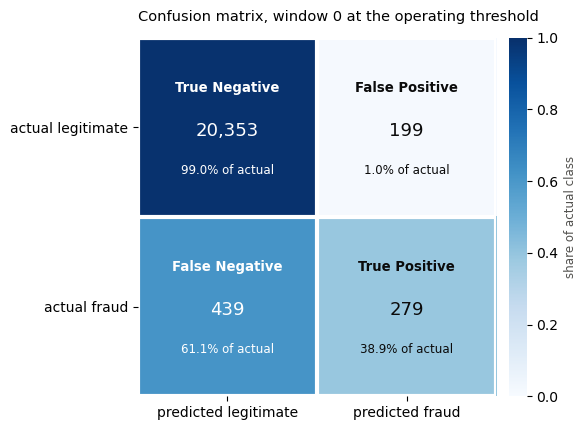

              precision    recall  f1-score   support

  legitimate     0.9789    0.9903    0.9846     20552
       fraud     0.5837    0.3886    0.4666       718

    accuracy                         0.9700     21270
   macro avg     0.7813    0.6894    0.7256     21270
weighted avg     0.9655    0.9700    0.9671     21270



In [67]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

w0 = pd.read_parquet("data/splits/stream_w00.parquet")
Xw, yw = encode(w0), w0["isFraud"].values
pred = (bst.predict(xgb.DMatrix(Xw), iteration_range=RANGE) >= THRESH).astype(int)

cm  = confusion_matrix(yw, pred)
row = cm / cm.sum(axis=1, keepdims=True)
names = np.array([["True Negative", "False Positive"],
                  ["False Negative", "True Positive"]])

INK, MUTED = "#0b0b0b", "#52514e"

fig, ax = plt.subplots(figsize=(5.6, 4.4))
im = ax.imshow(row, cmap="Blues", vmin=0, vmax=1)

for i in range(2):
    for j in range(2):
        c = "white" if row[i, j] > 0.42 else INK
        ax.text(j, i-0.22, names[i, j], ha="center", va="center",
                fontsize=9.5, color=c, weight="bold")
        ax.text(j, i+0.02, f"{cm[i, j]:,}", ha="center", va="center",
                fontsize=13, color=c)
        ax.text(j, i+0.24, f"{row[i, j]:.1%} of actual", ha="center", va="center",
                fontsize=8.5, color=c)

ax.set_xticks([0, 1]); ax.set_xticklabels(["predicted legitimate", "predicted fraud"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["actual legitimate", "actual fraud"])
ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
ax.grid(which="minor", color="white", lw=3); ax.tick_params(which="minor", length=0)
for s in ax.spines.values():
    s.set_visible(False)

cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
cb.set_label("share of actual class", fontsize=8.5, color=MUTED)
cb.outline.set_visible(False)

ax.set_title("Confusion matrix, window 0 at the operating threshold",
             loc="left", fontsize=10.5, pad=12)
plt.tight_layout()
plt.savefig("figs/fig7_confusion.png", dpi=200, bbox_inches="tight")
plt.show()

print(classification_report(yw, pred, target_names=["legitimate", "fraud"], digits=4))
pd.DataFrame(cm, index=["actual_legit", "actual_fraud"],
             columns=["pred_legit", "pred_fraud"]).to_csv("evidence/T6_confusion_w0.csv")

Compares the three policies across the drifted windows using the Friedman test and, if significant, runs a Nemenyi post-hoc test, then saves the Friedman result.

In [3]:
%pip install scikit-posthocs --quiet
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

d = (three_arms[three_arms.window >= ONSET]
     .pivot(index="window", columns="policy", values="pr_auc")[["static","scheduled","psi"]])

stat, p = friedmanchisquare(d["static"], d["scheduled"], d["psi"])
print(f"n = {len(d)} drifted windows, k = 3 policies")
print(f"Friedman chi2 = {stat:.4f},  p = {p:.4f}\n")
print("mean ranks (1 = best):")
print(d.rank(axis=1, ascending=False).mean().round(2).to_string())

if p < 0.05:
    nem = sp.posthoc_nemenyi_friedman(d.values)
    nem.index = nem.columns = d.columns
    print("\nNemenyi post-hoc p-values:")
    print(nem.round(4).to_string())
else:
    print("\nNot significant at 0.05 — report the mean ranks and note the sample is 8 windows.")

pd.DataFrame([{"n": len(d), "chi2": round(stat,4), "p": round(p,4)}]).to_csv(
    "evidence/friedman.csv", index=False)

Note: you may need to restart the kernel to use updated packages.


NameError: name 'three_arms' is not defined

In [69]:
nem.to_csv("evidence/nemenyi.csv")

Creates and saves the main figures for the experiment, showing fraud rates, model performance against the monitor, PSI drift, policy comparisons, and the cost of different retraining thresholds.

In [2]:
import matplotlib.pyplot as plt

BLUE, ORANGE, GREEN = "#2a78d6", "#eb6834", "#0f9d76"
RED, INK, MUTED, GRID, BAND = "#d92d20", "#0b0b0b", "#52514e", "#dedcd8", "#f0efec"

plt.rcParams.update({
    "font.size": 9.5, "axes.titlesize": 10.5, "axes.labelsize": 9.5,
    "axes.edgecolor": MUTED, "text.color": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "figure.facecolor": "white",
    "axes.facecolor": "white", "legend.frameon": False,
})

def clean(ax):
    ax.grid(axis="y", color=GRID, lw=0.7); ax.set_axisbelow(True)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_linewidth(0.8)

ctrl  = pd.read_csv("evidence/control_no_injection.csv")
piv   = pd.read_csv("evidence/pr_auc_by_window.csv", index_col=0)
swp   = pd.read_csv("evidence/threshold_sweep.csv").sort_values("train_secs")
ptr   = three_arms[three_arms.policy == "psi"].psi_mean.values
Wx    = list(range(N_WINDOWS))

# prevalence (fraud rate)
fig, ax = plt.subplots(figsize=(7.2, 2.9))
ax.bar(Wx, ctrl.fraud_rate*100, color=BLUE, width=0.62)
ax.axhline(ctrl.fraud_rate.mean()*100, color=MUTED, lw=1, ls=(0,(4,3)))
ax.annotate(f"mean {ctrl.fraud_rate.mean()*100:.2f}%", xy=(11.4, ctrl.fraud_rate.mean()*100),
            xytext=(0,4), textcoords="offset points", ha="right", fontsize=8.5, color=MUTED)
ax.set_xticks(Wx); ax.set_xlabel("Stream window (7 days)"); ax.set_ylabel("Fraud rate (%)")
ax.set_title("Target prevalence across the replayed stream", loc="left")
clean(ax); plt.tight_layout()
plt.savefig("figs/fig2_prevalence.png", dpi=200, bbox_inches="tight"); plt.show()

# Control: performance vs monitor
fig, (a1, a2) = plt.subplots(2, 1, figsize=(7.2, 5.0), sharex=True,
                             gridspec_kw={"height_ratios":[1.25,1]})
a1.plot(Wx, ctrl.pr_auc, color=BLUE, lw=2, marker="o", ms=6)
a1.annotate(f"best  {ctrl.pr_auc.max():.3f}", xy=(ctrl.pr_auc.idxmax(), ctrl.pr_auc.max()),
            xytext=(6,10), textcoords="offset points", fontsize=8.5, color=BLUE)
a1.annotate(f"worst  {ctrl.pr_auc.min():.3f}", xy=(ctrl.pr_auc.idxmin(), ctrl.pr_auc.min()),
            xytext=(6,-16), textcoords="offset points", fontsize=8.5, color=BLUE)
a1.set_ylabel("PR-AUC"); a1.set_ylim(.33,.60); clean(a1)
a1.set_title("Performance varies while the monitor stays flat (no drift injected)", loc="left")
a2.plot(Wx, ctrl.psi_mean, color=GREEN, lw=2, marker="s", ms=5.5)
a2.axhline(.10, color=MUTED, lw=1, ls=(0,(5,4)))
a2.annotate("conventional investigate band, 0.10", xy=(0.1,.104), fontsize=8.5, color=MUTED)
a2.set_ylabel("Mean PSI"); a2.set_ylim(0,.135); a2.set_xticks(Wx)
a2.set_xlabel("Stream window (7 days)"); clean(a2); plt.tight_layout()
plt.savefig("figs/fig3_control.png", dpi=200, bbox_inches="tight"); plt.show()

# The three arms
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.axvspan(ONSET-0.5, 11.5, color=BAND, lw=0)
ax.annotate("injected drift →", xy=(ONSET-0.3, .565), fontsize=8.5, color=MUTED)
ax.plot(Wx, piv.static,    color=BLUE,   lw=2, marker="o", ms=5.5, label="A · static (0 retrains)")
ax.plot(Wx, piv.scheduled, color=ORANGE, lw=2, marker="s", ms=5.5, label="B · scheduled (3 retrains)")
ax.plot(Wx, piv.psi,       color=GREEN,  lw=2, marker="^", ms=6.5, label="C · PSI-triggered (8 retrains)")
ax.set_xticks(Wx); ax.set_ylim(.28,.60)
ax.set_xlabel("Stream window (7 days)"); ax.set_ylabel("PR-AUC")
ax.set_title("Retraining policy comparison across the replayed stream", loc="left")
ax.legend(loc="lower left", fontsize=8.8); clean(ax); plt.tight_layout()
plt.savefig("figs/fig4_three_arms.png", dpi=200, bbox_inches="tight"); plt.show()

# PSI trace against thresholds
fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.axvspan(ONSET-0.5, 11.5, color=BAND, lw=0)
ax.plot(Wx, ptr, color=GREEN, lw=2, marker="o", ms=5.5, zorder=3)
ax.axhline(.250, color=RED, lw=1.2, ls=(0,(5,4)))
ax.axhline(.100, color=ORANGE, lw=1.2, ls=(0,(5,4)))
ax.axhline(TAU,  color=BLUE, lw=1.2, ls=(0,(1.5,2)))
ax.annotate("conventional action band  τ = 0.25 — never fires", xy=(-0.35,.258),
            fontsize=8.3, color=RED, ha="left")
ax.annotate("investigate band  τ = 0.10 — detects 1 of 8", xy=(11.45,.112),
            fontsize=8.3, color=ORANGE, ha="right")
ax.annotate(f"calibrated  τ = {TAU:.3f} — detects 8 of 8, latency 0", xy=(11.45,TAU+.006),
            fontsize=8.3, color=BLUE, ha="right")
ax.annotate("onset", xy=(ONSET, ptr[ONSET]), xytext=(1.3,.070), fontsize=8.5, color=MUTED,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=0.9))
ax.set_xticks(Wx); ax.set_ylim(0,.30); ax.set_xlim(-0.6, 11.6)
ax.set_xlabel("Stream window (7 days)"); ax.set_ylabel("Mean PSI (20 monitored features)")
ax.set_title("Drift signal against conventional and calibrated thresholds", loc="left")
clean(ax); plt.tight_layout()
plt.savefig("figs/fig5_psi_trace.png", dpi=200, bbox_inches="tight"); plt.show()

# cost-performance curve
fig, ax = plt.subplots(figsize=(7.4, 4.3))
ax.plot(swp.train_secs, swp.mean_pr_auc_drift, color=BLUE, lw=2, marker="o", ms=8, zorder=3)
for t, dx, dy, lab in [(0.250, 10, 2, "τ = 0.25\nnever fires"),
                       (0.100, 10, -4, "τ = 0.10"),
                       (0.075, -16, 14, "τ = 0.050 / 0.075\ncalibrated"),
                       (0.020, -8, -30, "τ = 0.020\n3 false alarms")]:
    r = swp[swp.tau == t].iloc[0]
    ax.annotate(lab, (r.train_secs, r.mean_pr_auc_drift), textcoords="offset points",
                xytext=(dx, dy), fontsize=8.5, color=MUTED,
                ha="right" if dx < 0 else "left")
sch = summary[summary.arm == "scheduled"].iloc[0]
ax.plot([sch.train_secs], [sch.mean_pr_auc_drift], marker="s", ms=8, color=ORANGE, zorder=4)
ax.annotate("scheduled retraining\nevery 3 windows",
            (sch.train_secs, sch.mean_pr_auc_drift), textcoords="offset points",
            xytext=(16,-6), fontsize=8.5, color=ORANGE,
            arrowprops=dict(arrowstyle="->", color=ORANGE, lw=0.9))
ax.annotate("+166% compute buys +4.1% PR-AUC", xy=(96,.3915), fontsize=8.8, color=INK)
ax.set_xlabel("Retraining compute (seconds)"); ax.set_ylabel("Mean PR-AUC over drifted windows")
ax.set_title("Cost–performance frontier for threshold selection", loc="left")
ax.set_xlim(-14, 262); ax.set_ylim(.378,.464); clean(ax); plt.tight_layout()
plt.savefig("figs/fig6_frontier.png", dpi=200, bbox_inches="tight"); plt.show()

print(sorted(os.listdir("figs")))

NameError: name 'pd' is not defined

In [1]:
import os, json, boto3, xgboost as xgb

BUCKET = os.environ.get("BUCKET", "main-drift-detection-bucket")

with open("evidence/config.json") as f:
    config = json.load(f)

bst = xgb.Booster()
bst.load_model("models/champion.json")

config["params"] = {"objective": "binary:logistic", "eval_metric": "aucpr",
                    "seed": config["SEED"], "max_depth": 6, "eta": 0.1}
config["val_pr_auc"] = float(bst.attributes()["best_score"])

with open("evidence/config.json", "w") as f:
    json.dump(config, f, indent=2)

s3 = boto3.client("s3")
n = 0
for folder in ["evidence", "figs", "models"]:
    for fn in sorted(os.listdir(folder)):
        path = f"{folder}/{fn}"
        if not os.path.isfile(path) or fn.startswith("."):
            continue
        s3.upload_file(path, BUCKET, f"results/{folder}/{fn}")
        n += 1
print(f"uploaded {n} files to s3://{BUCKET}/results/")

uploaded 26 files to s3://main-drift-detection-bucket/results/


In [ ]:
import json, boto3

config = {
    "SEED": SEED, "BEST_ITER": BEST_ITER,
    "THRESH": float(THRESH), "TAU": float(TAU),
    "WINDOW_DAYS": WINDOW_DAYS, "N_WINDOWS": N_WINDOWS,
    "GAP_WINDOWS": GAP_WINDOWS, "ONSET": ONSET, "RETRAIN_ROWS": RETRAIN_ROWS,
    "MIN_COVERAGE": MIN_COVERAGE, "MIN_BINS": MIN_BINS,
    "MIN_BIN_PROP": MIN_BIN_PROP, "N_BINS": N_BINS, "N_MONITOR": N_MONITOR,
    "monitored": monitored,
    "val_pr_auc": 0.5098,
    "injection_targets": ["C4", "C8", "C14", "card6", "TransactionAmt"],
}
with open("evidence/config.json", "w") as f:
    json.dump(config, f, indent=2)

s3 = boto3.client("s3")
n = 0
for folder in ["evidence", "figs", "models"]:
    for fn in sorted(os.listdir(folder)):
        path = f"{folder}/{fn}"
        if not os.path.isfile(path) or fn.startswith("."):
            contiune
        s3.upload_file(path, BUCKET, f"results/{folder}/{fn}")
        n += 1
print(f"uploaded {n} files to s3://{BUCKET}/results/")

In [5]:
import shutil, os

ignore = shutil.ignore_patterns(".ipynb_checkpoints", ".*")
shutil.rmtree("bundle", ignore_errors=True)
for d in ("evidence", "figs", "models"):
    shutil.copytree(d, f"bundle/{d}", ignore=ignore)

shutil.make_archive("results_15aug", "zip", "bundle")
shutil.rmtree("bundle")

print(f"results_15aug.zip  {os.path.getsize('results_15aug.zip')/1e6:.2f} MB")

results_15aug.zip  1.21 MB


In [7]:
%%writefile .gitignore
data/
*.parquet
*.csv
*.tar.gz
*.zip
.ipynb_checkpoints/
bundle/
!evidence/*.csv

Overwriting .gitignore


In [8]:
!ls -a
!cat .gitignore

.		    .jupyter			     mainwork.ipynb
..		    .kiro			     mainwork_public.ipynb
.agent		    .local			     models
.bashrc		    .npm			     pipeline_data
.cache		    .sagemaker_sql_editor_api_cache  results_15aug.zip
.claude		    .virtual_documents		     results_backup.zip
.config		    data			     results_bundle.zip
.gitignore	    download			     scripts
.ipynb_checkpoints  evidence
.ipython	    figs
data/
*.parquet
*.csv
*.tar.gz
*.zip
.ipynb_checkpoints/
bundle/
!evidence/*.csv
